In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data=pd.read_csv("C:\\Users\\sajay\\Downloads\\Food_Delivery_Times.csv")
print(data.head(3))
print(data.columns)


   Order_ID  Distance_km Weather Traffic_Level Time_of_Day Vehicle_Type  \
0       522         7.93   Windy           Low   Afternoon      Scooter   
1       738        16.42   Clear        Medium     Evening         Bike   
2       741         9.52   Foggy           Low       Night      Scooter   

   Preparation_Time_min  Courier_Experience_yrs  Delivery_Time_min  
0                    12                     1.0                 43  
1                    20                     2.0                 84  
2                    28                     1.0                 59  
Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')


In [63]:
data.isnull().sum()
data.dtypes
data.shape
data.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


In [64]:
a=data.columns

#check for unique and value_counts iof each column

for i in a:
    print(f"column name",{i})
    print(data[i].unique())
    print(data[i].value_counts())
    print("============================")

column name {'Order_ID'}
[ 522  738  741  661  412  679  627  514  860  137  812   77  637  974
  939  900  281  884  762  320  550  175  372  528  211  236  102  987
  903  948  347  140  622  500  371  199  688  585  902   60  329   97
  313  975  300  278  925  602  440  838  571  880  262  579   24   31
  618   11  222  821  297   55  543  210  605  693  663  867   71  544
  108  494  591  742  293  290  653   40  590  308  680   67  276   68
  319  549  999  715  754  328  383  452  523  219  788  437  765   89
   64  827  717  352  937  257  636  645  555  960  169  918  529  824
  986  817   87  433  185  979  535  295  893  426  714  261  238  560
  584  446  868  801  600  850  266  996  530   56  121  216   26   73
   45  248  722  282  894  915  811  245  823  322  644  159  978  430
  942  463  310  698   61  885  596  768  650  651  866  669  299  690
  315  311  362  480  111  990  487  364  255  260  803  678  495  671
  378  527  846  138  356  366  943  750  949  830  

In [65]:
data.columns=data.columns.str.lower()
data.columns

Index(['order_id', 'distance_km', 'weather', 'traffic_level', 'time_of_day',
       'vehicle_type', 'preparation_time_min', 'courier_experience_yrs',
       'delivery_time_min'],
      dtype='object')

In [66]:
#filling the null values
data["weather"].ffill(inplace=True)

data["traffic_level"].ffill(inplace=True)

data["time_of_day"].ffill(inplace=True)

data["courier_experience_yrs"].fillna(data["courier_experience_yrs"].mean(),inplace=True)

data.isna().sum()

C:\Users\sajay\AppData\Local\Temp\ipykernel_34588\728591872.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["weather"].ffill(inplace=True)
C:\Users\sajay\AppData\Local\Temp\ipykernel_34588\728591872.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doin

order_id                  0
distance_km               0
weather                   0
traffic_level             0
time_of_day               0
vehicle_type              0
preparation_time_min      0
courier_experience_yrs    0
delivery_time_min         0
dtype: int64

In [67]:
data[["weather","traffic_level","time_of_day"]]


,weather,traffic_level,time_of_day
0,Windy,Low,Afternoon
1,Clear,Medium,Evening
2,Foggy,Low,Night
3,Rainy,Medium,Afternoon
4,Clear,Low,Morning
...,...,...,...
995,Clear,High,Evening
996,Rainy,Low,Morning
997,Snowy,High,Evening
998,Clear,Low,Afternoon


In [68]:
#min and max values
print("maximum courier experince",data["courier_experience_yrs"].min())
print("minimum courier experince",data["courier_experience_yrs"].max())

maximum courier experince 0.0
minimum courier experince 9.0


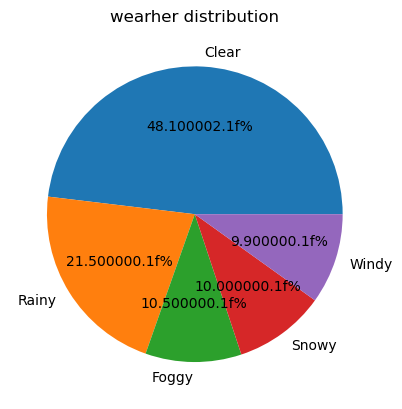

In [69]:
#vizualization
data["weather"].unique()
#orders in diffrent weather condition
weather=data["weather"].value_counts()
a=weather.index
b=weather.values
plt.pie(b,labels=a,autopct="%1f.1f%%")
plt.title("wearher distribution")
plt.show()


In [70]:
#orders in diffrent distances
distances=data["distance_km"]


bins=[1,2,3,4,5,6,7,8]
labels=[5,10,15,20]
data["distance_km"]=pd.cut(data["distance_km"],bins=bins,labels=labels)
plt.bar(dist.index,bins=dist.values)
plt.show()

ValueError: Bin labels must be one fewer than the number of bin edges

In [71]:
data.corr(numeric_only=True)["delivery_time_min"]

order_id                 -0.036650
distance_km               0.780998
preparation_time_min      0.307350
courier_experience_yrs   -0.089066
delivery_time_min         1.000000
Name: delivery_time_min, dtype: float64

In [72]:
data.drop('order_id',axis=1,inplace=True)
data.columns

Index(['distance_km', 'weather', 'traffic_level', 'time_of_day',
       'vehicle_type', 'preparation_time_min', 'courier_experience_yrs',
       'delivery_time_min'],
      dtype='object')

In [73]:
#data encoding
#weather ,time_of_day,vechile_type--nominal--dummy/onehot encoding
#traffic level is --ordinaldata--label/mapping

from sklearn.preprocessing import LabelEncoder

lb=LabelEncoder()

data["traffic_level"]=lb.fit_transform(data["traffic_level"])

data["traffic_level"]

0      1
1      2
2      1
3      2
4      1
      ..
995    0
996    1
997    0
998    1
999    1
Name: traffic_level, Length: 1000, dtype: int64

In [74]:
data=pd.get_dummies(data,columns=["weather","time_of_day","vehicle_type"],drop_first=True,dtype=int)
data


,distance_km,traffic_level,preparation_time_min,courier_experience_yrs,delivery_time_min,weather_Foggy,weather_Rainy,weather_Snowy,weather_Windy,time_of_day_Evening,time_of_day_Morning,time_of_day_Night,vehicle_type_Car,vehicle_type_Scooter
0,7.93,1,12,1.0,43,0,0,0,1,0,0,0,0,1
1,16.42,2,20,2.0,84,0,0,0,0,1,0,0,0,0
2,9.52,1,28,1.0,59,1,0,0,0,0,0,1,0,1
3,7.44,2,5,1.0,37,0,1,0,0,0,0,0,0,1
4,19.03,1,16,5.0,68,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,8.50,0,13,3.0,54,0,0,0,0,1,0,0,1,0
996,16.28,1,8,9.0,71,0,1,0,0,0,1,0,0,1
997,15.62,0,26,2.0,81,0,0,1,0,1,0,0,0,1
998,14.17,1,8,0.0,55,0,0,0,0,0,0,0,0,0


In [75]:
#labeling of the data
x=data.drop("delivery_time_min",axis=1)
y=data["delivery_time_min"]

print(x.columns)

Index(['distance_km', 'traffic_level', 'preparation_time_min',
       'courier_experience_yrs', 'weather_Foggy', 'weather_Rainy',
       'weather_Snowy', 'weather_Windy', 'time_of_day_Evening',
       'time_of_day_Morning', 'time_of_day_Night', 'vehicle_type_Car',
       'vehicle_type_Scooter'],
      dtype='object')


In [76]:
#spliting data for train and text

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 13)
(200, 13)
(800,)
(200,)


In [77]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,y_train)

predict=lr.predict(X_test)



In [78]:
#model evalution techniques
#checking result based y_test

print("R^2 score of lr Testing set:",lr.score(X_test,y_test))
print("R^2 score of lr Training set:",lr.score(X_train,y_train))

from sklearn.metrics import mean_absolute_error as mae,mean_squared_error as mse

print("Mean absolute error:",mae(y_test,predict))
print("Mean squared error:",mse(y_test,predict))
print("root mean squared error:",np.sqrt(mse(y_test,predict)))

R^2 score of lr Testing set: 0.7756542528473223
R^2 score of lr Training set: 0.7335314563364437
Mean absolute error: 6.976293721049468
Mean squared error: 100.55781560035959
root mean squared error: 10.027851993341326


In [79]:
#DecisionTreeRegressor
from sklearn.tree import DecisionTreeRegressor

dtr=DecisionTreeRegressor()

dtr.fit(X_train,y_train)

predict=dtr.predict(X_test)

print(dtr.score(X_train,y_train))
print(dtr.score(X_test,y_test))
print(mse(y_test,predict))
print(mae(y_test,predict))
print(np.sqrt(mse(y_test,predict)))

1.0
0.44687621712191683
247.925
10.515
15.745634315580938


In [80]:
#RandomforestREgressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
rfr=RandomForestRegressor()
gfr=GradientBoostingRegressor()

rfr.fit(X_train,y_train)
predict=rfr.predict(X_test)
print(rfr.score(X_train,y_train))
print(rfr.score(X_test,y_test))
print(mse(y_test,predict))
print(mae(y_test,predict))
print(np.sqrt(mse(y_test,predict)))



0.9565266513580403
0.7811858913667568
98.078386
7.008799999999999
9.903453236119207


In [81]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.fit_transform(X_test)
svr=SVR()
svr.fit(X_train,y_train)
predict=svr.predict(X_test)
print(svr.score(X_train,y_train))
print(svr.score(X_test,y_test))
print(mse(y_test,predict))
print(mae(y_test,predict))
print(np.sqrt(mse(y_test,predict)))


0.5748324447566346
0.6206580822216445
170.03128029649102
9.71907088741115
13.039604299843267


In [82]:
import joblib 

joblib.dump(lr,"model.pkl")
model=joblib.load("model.pkl")
joblib.dump(x.columns.tolist(),"model_coloumns.pkl")
joblib.dump(lb,"traffic_encoder.pkl")
print("model saved")

model saved


In [83]:
print(x.dtypes)

distance_km               float64
traffic_level               int64
preparation_time_min        int64
courier_experience_yrs    float64
weather_Foggy               int64
weather_Rainy               int64
weather_Snowy               int64
weather_Windy               int64
time_of_day_Evening         int64
time_of_day_Morning         int64
time_of_day_Night           int64
vehicle_type_Car            int64
vehicle_type_Scooter        int64
dtype: object


In [85]:
distance_km=int(input("Enter the distance in km"))
traffic_level=int(input("Enter the traffic level (1-3)"))
preparation_time_min=int(input("Enter the time for prepare"))
courier_experience_yrs=int(input("Enter the year"))
weather=input("Weather of the day (Windy,Sunny,Foggy,Rainy)")
time_of_day=input("Enter the time of day")
vehicle=input("Vechile(car/scooter)")



Enter the distance in km 50
Enter the traffic level (1-3) 2
Enter the time for prepare 10
Enter the year 2
Weather of the day (Windy,Sunny,Foggy,Rainy) Rainy
Enter the time of day Night
Vechile(car/scooter) Car


In [ ]:
input_dict = {
    "distance_km": distance_km,
    "traffic_level": traffic_level,
    "preparation_time_min": preparation_time_min,
    "courier_experience_yrs": courier_experience_yrs,


"weather_Foggy":1 if weather=="Foggy" else 0,
"weather_Rainy":1 if weather=="Rainy" else 0,
"weather_Snowy":1 if weather=="Snowy" else 0,
"weather_Windy":1 if weather=="Windy" else 0,

"time_of_day_Evening":1 if time_of_day=="Evening " else 0,
"time_of_day_Morning" :1 if time_of_day=="Morning " else 0,        
"time_of_day_Night":1 if time_of_day=="Night " else 0,

"vehicle_type_Car": 1 if vehicle == "Car" else 0,
    "vehicle_type_Scooter": 1 if vehicle == "Scooter" else 0
}


In [89]:
input_df=pd.DataFrame([input_dict])
input_df=input_df.reindex(columns=x.columns,fill_value=0)

prediction_model=model.predict(input_df)

print(f"predicted deliver time{prediction_model[0]:.2f}minutes")

predicted deliver time172.40minutes


In [90]:
data.sample()


,distance_km,traffic_level,preparation_time_min,courier_experience_yrs,delivery_time_min,weather_Foggy,weather_Rainy,weather_Snowy,weather_Windy,time_of_day_Evening,time_of_day_Morning,time_of_day_Night,vehicle_type_Car,vehicle_type_Scooter
933,19.1,1,18,1.0,101,0,0,1,0,0,0,0,0,0
